Importing the Libraries

In [1]:
import time
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

Loading the Dataset 

In [2]:
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

Benchmarking and Cross-Validation for Random Forest Regressor and Gradient Boosting Regressor

In [3]:
n_estimators_list = [10,50,100,250,500]

rf_scores = []
rf_times = []

gbt_scores = []
gbt_times = []

for n in n_estimators_list:
    # initializing the models with the current number of estimators
    rf = RandomForestRegressor(n_estimators=n, random_state=42, n_jobs = -1)
    gbt = GradientBoostingRegressor(n_estimators=n, random_state=42)
     
    # evaluation of elasped time and cross validation scores for random forest model 
    start_time_rf = time.time()

    # change cv from 3 to 5, as the assignment requires 5-fold cross validation
    scores_rf = cross_val_score(rf, X, y, cv=5, scoring='r2')

    end_time_rf = time.time()

    elapsed_time_rf = end_time_rf - start_time_rf
    
    # calculating the mean R2 score for random forest and storing the results
    mean_score_rf = np.mean(scores_rf)
    rf_scores.append(mean_score_rf)
    rf_times.append(elapsed_time_rf)
    
    print(f"RF (n={n}): R2={mean_score_rf:.4f}, Time={elapsed_time_rf:.2f}s")


    

    # evaluation of elasped time and cross validation scores for gradient boosting model
    start_time_gbt = time.time()
    
    # change cv from 3 to 5, as the assignment requires 5-fold cross validation
    scores_gbt = cross_val_score(gbt, X, y, cv=5, scoring='r2')

    end_time_gbt = time.time()

    elapsed_time_gbt = end_time_gbt - start_time_gbt
    
    # calculating the mean R2 score for gradient boosting and storing the results
    mean_score_gbt = np.mean(scores_gbt)
    gbt_scores.append(mean_score_gbt)
    gbt_times.append(elapsed_time_gbt)


    print(f"GBT (n={n}): R2={mean_score_gbt:.4f}, Time={elapsed_time_gbt:.2f}s")

RF (n=10): R2=0.6234, Time=0.94s
GBT (n=10): R2=0.4396, Time=1.37s
RF (n=50): R2=0.6493, Time=3.07s
GBT (n=50): R2=0.6330, Time=6.60s
RF (n=100): R2=0.6561, Time=5.42s
GBT (n=100): R2=0.6698, Time=13.19s
RF (n=250): R2=0.6557, Time=12.43s
GBT (n=250): R2=0.6878, Time=33.29s
RF (n=500): R2=0.6557, Time=25.24s
GBT (n=500): R2=0.6922, Time=66.72s


Plotting R2 Scores vs. N-Estimators For Both Models

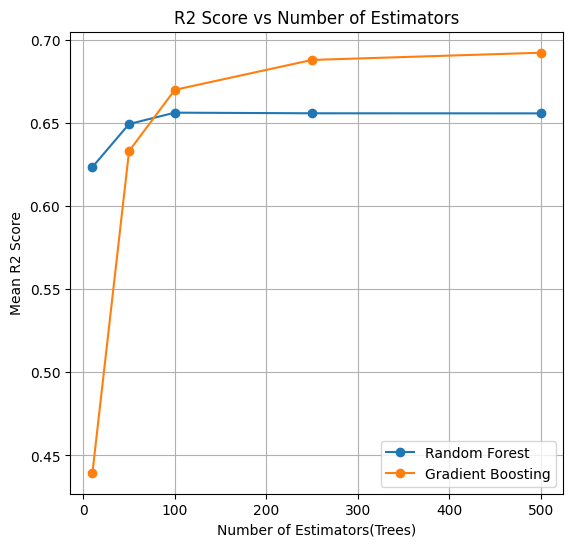

In [4]:
plt.figure(figsize =(14,6))
plt.subplot(1, 2, 1)

plt.plot(n_estimators_list, rf_scores, marker='o', label='Random Forest')
plt.plot(n_estimators_list, gbt_scores, marker='o', label='Gradient Boosting')
plt.title("R2 Score vs Number of Estimators")
plt.xlabel("Number of Estimators(Trees)")
plt.ylabel("Mean R2 Score")
plt.legend()
plt.grid(True)

Plotting Elapsed Time vs. N-Estimators For Both Models

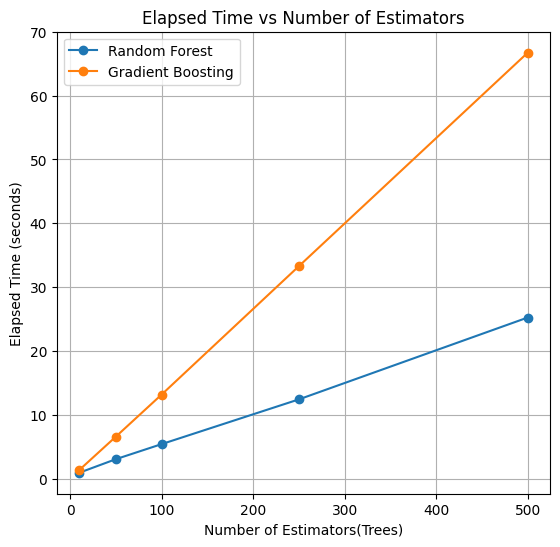

In [5]:
plt.figure(figsize =(14,6))
plt.subplot(1, 2, 1)

plt.plot(n_estimators_list, rf_times, marker='o', label='Random Forest')
plt.plot(n_estimators_list, gbt_times, marker='o', label='Gradient Boosting')
plt.title("Elapsed Time vs Number of Estimators")
plt.xlabel("Number of Estimators(Trees)")
plt.ylabel("Elapsed Time (seconds)")
plt.legend()
plt.grid(True)

Interpretation of Results


Gain in $R^{2}$ vs. Training Time:

The gain in the $R^{2}$ score between 100 and 500 trees is generally marginal for both models. Once the models reach around 100 estimators, performance plateaus due to diminishing returns. However, the total training time continues to scale linearly as more trees are added. Therefore, the increase in training time is not proportional to the negligible increase in accuracy. 


Model Stabilization:
 
Random Forest stabilizes without the risk of performance degradation at high tree counts. Because Random Forest utilizes Bagging (Bootstrap Aggregating), each tree is built independently. Adding more trees simply averages out the predictions, which reduces the variance of the ensemble without increasing the bias. Gradient Boosting, conversely, builds trees sequentially to correct the errors of previous trees; if you add too many trees without early stopping, it risks overfitting the training data.


Edge Device Deployment: 

For deployment on a low-performance edge device with very limited RAM and CPU , Gradient Boosting is typically the better choice to balance complexity and performance. As the hint suggests, the number of trees (n_estimators) only tells one part of the story. Random Forests generally construct fully grown, very deep trees, which results in a massive overall model size and high memory footprint. Gradient Boosting models use "weak learners," meaning they construct very shallow trees (often with a maximum depth of 3). Evaluating 100 shallow GBT trees during inference requires significantly fewer memory lookups and conditional checks compared to evaluating 100 deep RF trees, making GBT much more efficient for constrained hardware environments.

In [6]:
!jupyter nbconvert --to html MLS2_A07_Somuncu.ipynb

[NbConvertApp] Converting notebook MLS2_A07_Somuncu.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 399017 bytes to MLS2_A07_Somuncu.html
